# SVM with RBF Kernel — Augmented Dataset (500 per class)
## Wisconsin Breast Cancer Dataset
### Pipeline: Load → 80/20 Split → Scale → Train SVM(rbf) → Blue Visualizations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

sns.set_palette('Blues')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Blues(np.linspace(0.3, 0.9, 8)))

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../../augmented_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")

Dataset shape: (1000, 31)
Class distribution:
diagnosis
1    500
0    500
Name: count, dtype: int64


In [3]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized.")

Features standardized.


In [5]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
print("SVM RBF trained.")

SVM RBF trained.


In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
roc_auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("SVM RBF Kernel — Augmented Data Results")
print("=" * 50)
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")
print(f"\nConfusion Matrix:\n              Predicted\n              Neg    Pos\nActual Neg    {tn:3d}   {fp:2d}\n       Pos    {fn:2d}   {tp:3d}")

SVM RBF Kernel — Augmented Data Results
Accuracy:     0.9800
Precision:    1.0000
Recall:       0.9600
F1-score:     0.9796
Specificity:  1.0000
ROC-AUC:      0.9946

Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg    100    0
       Pos     4    96


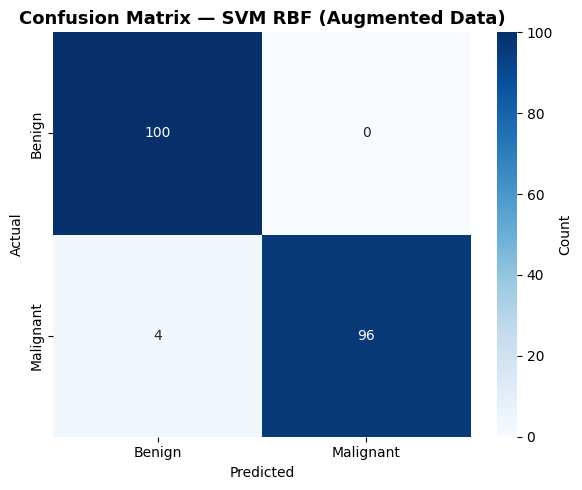

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — SVM RBF (Augmented Data)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

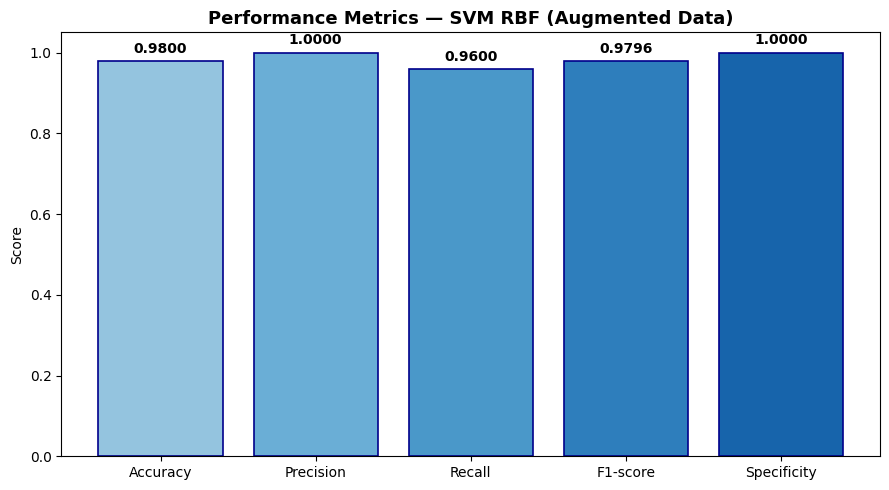

In [8]:
names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity']
vals = [accuracy, precision, recall, f1, specificity]
colors = plt.cm.Blues([0.4, 0.5, 0.6, 0.7, 0.8])
plt.figure(figsize=(9, 5))
bars = plt.bar(names, vals, color=colors, edgecolor='darkblue', linewidth=1.2)
plt.ylim(0, 1.05)
plt.title('Performance Metrics — SVM RBF (Augmented Data)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

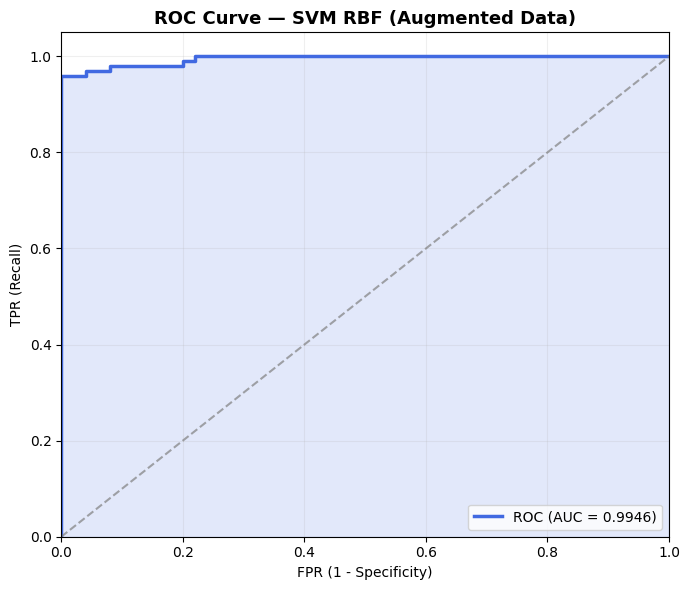

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.15, color='royalblue')
plt.plot([0, 1], [0, 1], 'gray', ls='--', alpha=0.7)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('FPR (1 - Specificity)')
plt.ylabel('TPR (Recall)')
plt.title('ROC Curve — SVM RBF (Augmented Data)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()